    student_id  age  gender  study_hours_per_day  sleep_hours  phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  breaks_per_day  coffee_intake_mg  exercise_minutes  assignments_completed  attendance_percentage  stress_level  focus_score  final_grade  productivity_score
0            1   23       0                 4.35         3.63               3.38                2.73           1.83          5.26               6               347               111                      2                  57.21            10           57        81.87               33.78
1            2   20       1                 6.14         6.58               5.48                1.51           3.13          1.73              13               403                28                     10                  91.27            10           49        60.90               48.99
2            3   29       0                 4.98         3.26               4.83                3.63           0.18          4.71       

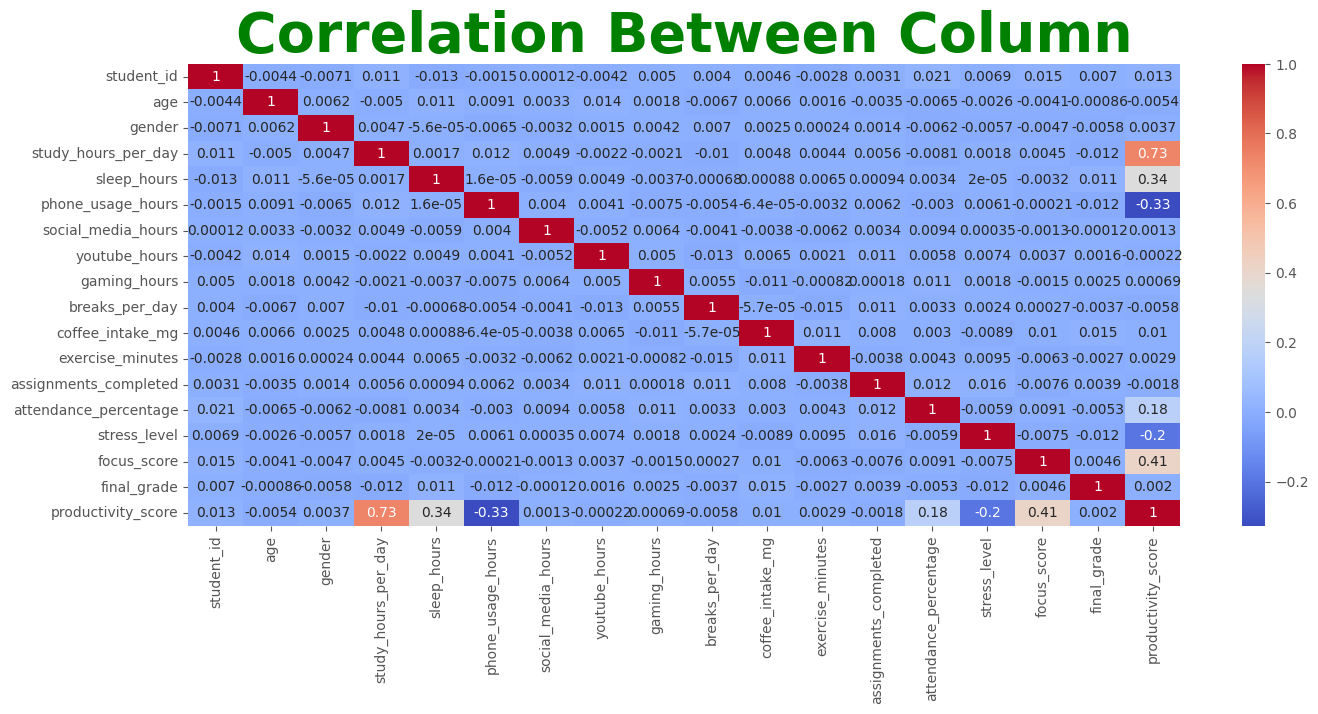

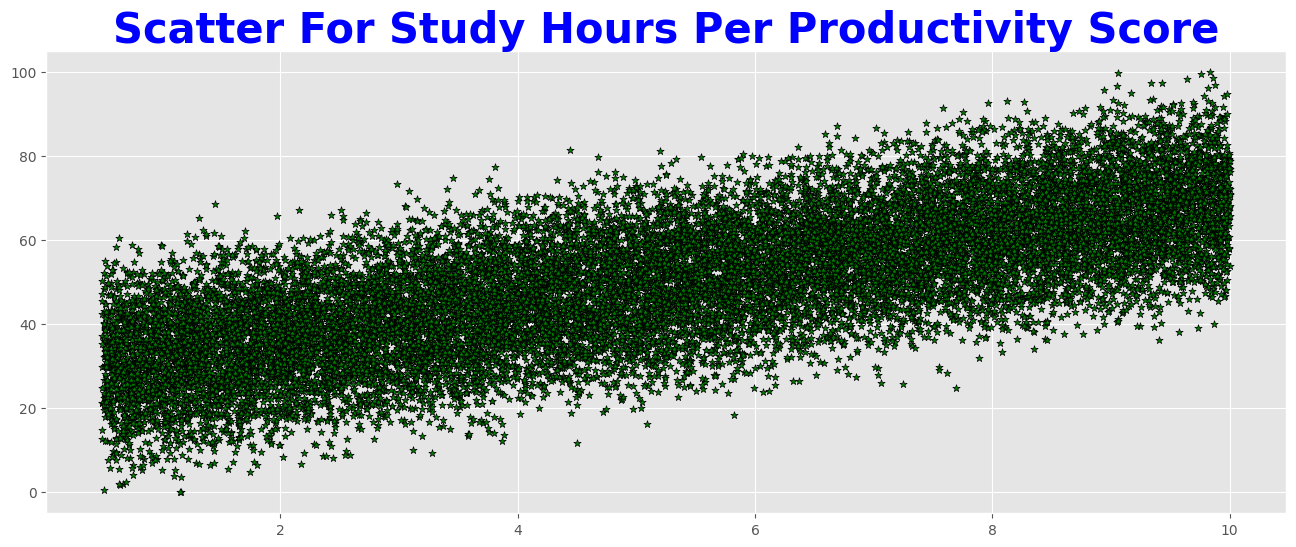

    student_id  age  gender  study_hours_per_day  sleep_hours  phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  breaks_per_day  coffee_intake_mg  exercise_minutes  assignments_completed  attendance_percentage  stress_level  focus_score  final_grade  productivity_score          A       B
0            1   23       0                 4.35         3.63               3.38                2.73           1.83          5.26               6               347               111                      2                  57.21            10           57        81.87               33.78  20.208812  247.95
1            2   20       1                 6.14         6.58               5.48                1.51           3.13          1.73              13               403                28                     10                  91.27            10           49        60.90               48.99   8.343687  300.86
2            3   29       0                 4.98         3.26               4.8

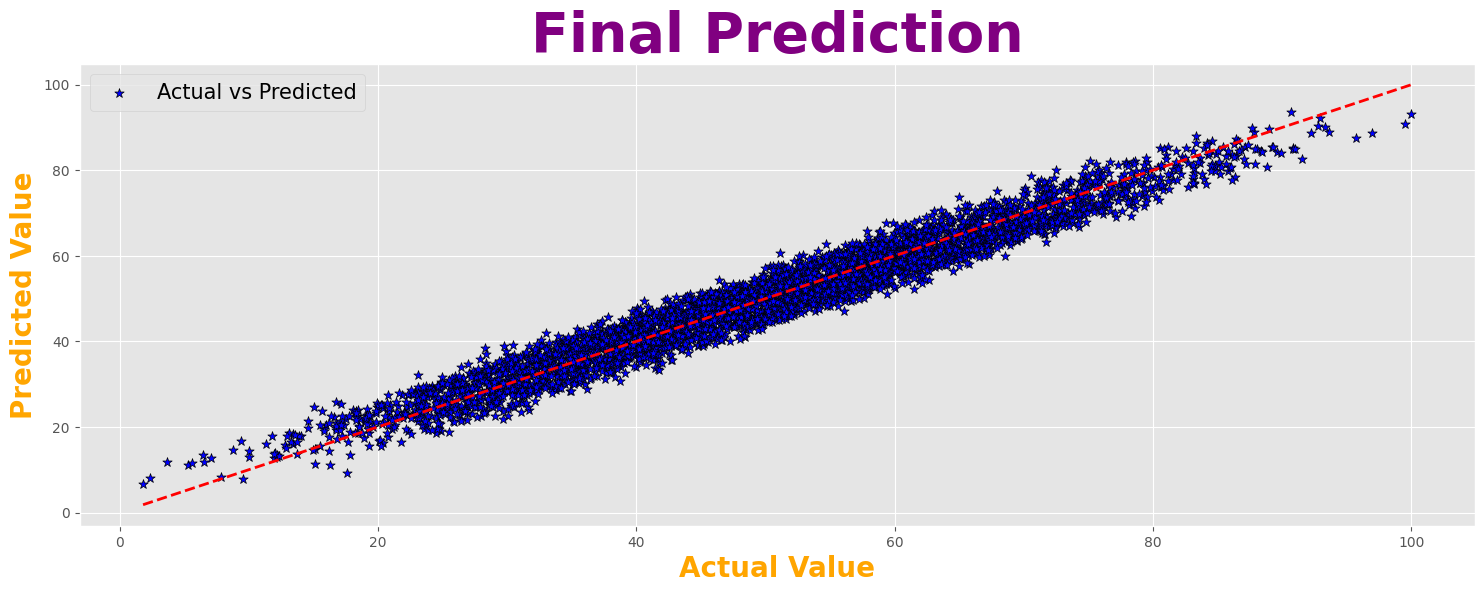

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
plt.style.use('ggplot')

pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.width',None)
pd.set_option('display.expand_frame_repr',False)

JP=pd.read_csv("student_productivity_dataset.csv")
# print(JP.head(20))

# print(JP.isna().sum())
# JP=JP[JP.duplicated()]
# print(JP)

from sklearn.preprocessing import LabelEncoder

JP['gender']=LabelEncoder().fit_transform(JP['gender'])
print(JP.head(20))

plt.figure(figsize=(16,6))
sns.heatmap(JP.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Between Column",fontsize=40,fontweight='bold',color='green')
plt.show()

# plt.figure(figsize=(16,6))
# plt.boxplot(JP['focus_score'])
# plt.show()

plt.figure(figsize=(16,6))
plt.scatter(JP['study_hours_per_day'],JP['productivity_score'],marker="*",s=30,color='green',edgecolor='black')
plt.title("Scatter For Study Hours Per Productivity Score",fontsize=30,fontweight='bold',color='blue')
plt.show()


JP['A']=JP['study_hours_per_day'] * JP['focus_score'] / JP['sleep_hours'] / JP['phone_usage_hours'] 
JP['B']=JP['study_hours_per_day'] * JP['focus_score']
print(JP.head(20)) 

x=JP[['study_hours_per_day','sleep_hours','attendance_percentage','focus_score','A','B']]
y=JP['productivity_score']

from sklearn.model_selection  import cross_val_score
from sklearn.ensemble import RandomForestRegressor

model=RandomForestRegressor(n_estimators=100,random_state=46)

score=cross_val_score(model,x,y,cv=5,scoring='r2')

print("CVS Score ==",score)
print("Average CVS ==",score.mean())


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=84)

# from sklearn.linear_model import LinearRegression

# model=LinearRegression()

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)


from sklearn.ensemble import RandomForestRegressor

model=RandomForestRegressor(n_estimators=100,random_state=85)

model.fit(x_train,y_train)
Y_Pred=model.predict(x_test)


Train=model.score(x_train,y_train)
Test=model.score(x_test,y_test)

print("Train Score == ",Train)
print("Test Score == ",Test)

from sklearn.metrics import mean_absolute_error ,r2_score

print("MAE == ",mean_absolute_error(y_test,Y_Pred))
print("R2 == ",r2_score(y_test,Y_Pred))

plt.figure(figsize=(18,6))
plt.scatter(y_test,Y_Pred,marker="*",s=50,color='blue',edgecolor='black',label="Actual vs Predicted")
plt.plot( [y_test.min(),y_test.max()] , [y_test.min(),y_test.max()],linewidth=2,linestyle="--",color='red')
plt.title("Final Prediction",fontsize=40,fontweight='bold',color='purple')
plt.xlabel("Actual Value",fontsize=20,fontweight='bold',color='orange')
plt.ylabel("Predicted Value",fontsize=20,fontweight='bold',color='orange')
plt.legend(loc='upper left',fontsize=15)
plt.show()